# 🧘 SinLlama Buddhist Q&A Evaluation (4-bit Quantized)

**Complete evaluation of SinLlama on Buddhist domain knowledge using 4-bit quantization**

This notebook:
- ✅ Loads SinLlama with PEFT adapters and 4-bit quantization
- ✅ Evaluates on 10 Buddhist Q&A questions (Sinhala + English)
- ✅ Calculates BERTScore, ROUGE, BLEU metrics
- ✅ Generates detailed analysis and visualizations
- ✅ Optimized for Google Colab (L4/T4 GPU)

**Runtime Required:** GPU (T4 or better recommended)

## 📦 Step 1: Install Required Libraries

In [ ]:
"""
🔧 Install/Update Required Libraries
Run this cell first, then RESTART RUNTIME before proceeding
"""

!pip install -q -U bitsandbytes transformers accelerate peft
!pip install -q evaluate bert-score rouge-score sacrebleu
!pip install -q pandas matplotlib seaborn plotly

print("✅ Installation complete!")
print("⚠️  IMPORTANT: Please restart the runtime now!")
print("   In Colab: Runtime → Restart runtime")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 31.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 11.5 MB/s eta 0:00:00
✅ Installation complete!
⚠️  IMPORTANT: Please restart the runtime now!
   In Colab: Runtime → Restart runtime


## 🔄 Step 2: System Check & Memory Cleanup

**Run this FIRST after restarting the runtime**

In [ ]:
"""
🔥 Memory Cleanup & System Verification
"""

import gc
import torch
import os
import sys

# Clear CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

# Set memory optimization
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

print("📦 Checking installed versions...\n")

# Verify critical libraries
import importlib.metadata

critical_libs = {
    'torch': '2.0.0',
    'transformers': '4.35.0',
    'bitsandbytes': '0.41.0',
    'peft': '0.6.0',
    'accelerate': '0.24.0'
}

all_good = True
for lib, min_ver in critical_libs.items():
    try:
        version = importlib.metadata.version(lib)
        print(f"   ✅ {lib}: {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"   ❌ {lib}: NOT INSTALLED")
        all_good = False

print("\n" + "="*60)

# Check GPU
if torch.cuda.is_available():
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    allocated = torch.cuda.memory_allocated(0) / 1e9
    reserved = torch.cuda.memory_reserved(0) / 1e9

    print(f"\n🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Total: {total_memory:.2f} GB")
    print(f"   Allocated: {allocated:.2f} GB")
    print(f"   Reserved: {reserved:.2f} GB")
    print(f"   FREE: {total_memory - allocated:.2f} GB")
    print(f"   CUDA Version: {torch.version.cuda}")
else:
    print("\n❌ No GPU available! 4-bit quantization requires CUDA.")
    all_good = False

print("\n" + "="*60)

if all_good:
    print("\n✅ System check passed! Ready to proceed.")
else:
    print("\n⚠️  Some issues detected. Please install missing libraries and restart.")

📦 Checking installed versions...

   ✅ torch: 2.8.0+cu126
   ✅ transformers: 4.57.1
   ✅ bitsandbytes: 0.48.2
   ✅ peft: 0.17.1
   ✅ accelerate: 1.11.0


🎮 GPU: NVIDIA L4
   Total: 23.80 GB
   Allocated: 0.00 GB
   Reserved: 0.00 GB
   FREE: 23.80 GB
   CUDA Version: 12.6


✅ System check passed! Ready to proceed.


## 📚 Step 3: Load Buddhist Questions Dataset

In [ ]:
"""
📚 Buddhist Questions Dataset
"""

import pandas as pd
from IPython.display import display

# Buddhist Questions Dataset
BUDDHIST_QUESTIONS = {
    "questions": [
        {
            "id": "Q001",
            "category": "Four Noble Truths",
            "difficulty": "easy",
            "question_sinhala": "සතර ආර්ය සත්‍යය මොනවාද?",
            "question_english": "What are the Four Noble Truths?",
            "reference_answer": "The Four Noble Truths are: (1) Dukkha - the truth of suffering, (2) Samudaya - the truth of the origin of suffering, (3) Nirodha - the truth of the cessation of suffering, and (4) Magga - the truth of the path leading to the cessation of suffering.",
            "source": "Dhammacakkappavattana Sutta (SN 56.11)"
        },
        {
            "id": "Q002",
            "category": "Noble Eightfold Path",
            "difficulty": "medium",
            "question_sinhala": "ආර්ය අෂ්ඨාංගික මාර්ගයේ අංග අටම වර්ග කරන්නේ කෙසේද?",
            "question_english": "How are the eight factors of the Noble Eightfold Path categorized?",
            "reference_answer": "The Noble Eightfold Path is divided into three categories: (1) Sīla (Virtue): Right Speech, Right Action, Right Livelihood; (2) Samādhi (Concentration): Right Effort, Right Mindfulness, Right Concentration; (3) Paññā (Wisdom): Right View, Right Intention.",
            "source": "Mahācattārīsaka Sutta (MN 117)"
        },
        {
            "id": "Q003",
            "category": "Three Characteristics",
            "difficulty": "easy",
            "question_sinhala": "ත්‍රිලක්ෂණය කියන්නේ මොනවාද?",
            "question_english": "What are the Three Characteristics (Tilakkhana)?",
            "reference_answer": "The Three Characteristics are: (1) Anicca - impermanence, (2) Dukkha - suffering or unsatisfactoriness, (3) Anattā - non-self or not-self.",
            "source": "Anattalakkhana Sutta (SN 22.59)"
        },
        {
            "id": "Q004",
            "category": "Meditation",
            "difficulty": "medium",
            "question_sinhala": "ආනාපානසති භාවනාව යනු කුමක්ද?",
            "question_english": "What is Ānāpānasati meditation?",
            "reference_answer": "Ānāpānasati is mindfulness of breathing meditation. It involves maintaining continuous attention on the breath - observing the in-breath and out-breath without controlling it, developing concentration and insight.",
            "source": "Ānāpānasati Sutta (MN 118)"
        },
        {
            "id": "Q005",
            "category": "Dependent Origination",
            "difficulty": "hard",
            "question_sinhala": "පටිච්ච සමුප්පාදයේ නිදන දොළොස කවරේද?",
            "question_english": "What are the twelve links of Dependent Origination?",
            "reference_answer": "The twelve links are: (1) Avijjā (ignorance), (2) Saṅkhāra (formations), (3) Viññāṇa (consciousness), (4) Nāma-rūpa (name-form), (5) Saḷāyatana (six sense bases), (6) Phassa (contact), (7) Vedanā (feeling), (8) Taṇhā (craving), (9) Upādāna (clinging), (10) Bhava (becoming), (11) Jāti (birth), (12) Jarā-maraṇa (aging-death).",
            "source": "Paṭiccasamuppāda Sutta (SN 12.1)"
        },
        {
            "id": "Q006",
            "category": "Precepts",
            "difficulty": "easy",
            "question_sinhala": "පඤ්ච ශීලය කියන්නේ මොනවාද?",
            "question_english": "What are the Five Precepts?",
            "reference_answer": "The Five Precepts are: (1) Refraining from killing living beings, (2) Refraining from taking what is not given, (3) Refraining from sexual misconduct, (4) Refraining from false speech, (5) Refraining from intoxicants that cloud the mind.",
            "source": "Veludvāreyyasutta (SN 55.7)"
        },
        {
            "id": "Q007",
            "category": "Buddha's Life",
            "difficulty": "easy",
            "question_sinhala": "බුදුරජාණන් වහන්සේ බුද්ධත්වය පළමුව ප්‍රකාශ කළේ කාට ද?",
            "question_english": "To whom did the Buddha first teach after his enlightenment?",
            "reference_answer": "The Buddha first taught the Dhamma to the group of five ascetics (Pañcavaggiya) at the Deer Park in Isipatana (Sarnath). This first sermon is known as Dhammacakkappavattana Sutta.",
            "source": "Dhammacakkappavattana Sutta (SN 56.11)"
        },
        {
            "id": "Q008",
            "category": "Four Brahmaviharas",
            "difficulty": "medium",
            "question_sinhala": "බ්‍රහ්මවිහාර සතර කවරේද?",
            "question_english": "What are the Four Brahmaviharas?",
            "reference_answer": "The Four Brahmaviharas are: (1) Mettā - loving-kindness, (2) Karuṇā - compassion, (3) Muditā - sympathetic joy, (4) Upekkhā - equanimity.",
            "source": "Metta Sutta (Sn 1.8)"
        },
        {
            "id": "Q009",
            "category": "Karma",
            "difficulty": "medium",
            "question_sinhala": "කර්මය සහ විපාකය අතර වෙනස කුමක්ද?",
            "question_english": "What is the difference between karma and its result?",
            "reference_answer": "Kamma refers to intentional actions (mental, verbal, or physical) that have moral consequences. Vipāka is the result or fruit of those actions that ripens later, bringing pleasant or unpleasant experiences according to the nature of the original action.",
            "source": "Nibbedhika Sutta (AN 6.63)"
        },
        {
            "id": "Q010",
            "category": "Five Aggregates",
            "difficulty": "hard",
            "question_sinhala": "පඤ්චස්කන්ධ පහක තිබෙන්නේ මොනවාද?",
            "question_english": "What are the Five Aggregates?",
            "reference_answer": "The Five Aggregates are: (1) Rūpa - form/material form, (2) Vedanā - feeling/sensation, (3) Saññā - perception, (4) Saṅkhāra - mental formations/volitional activities, (5) Viññāṇa - consciousness.",
            "source": "Khandha Saṃyutta (SN 22)"
        }
    ]
}

# Create DataFrame
df_questions = pd.DataFrame(BUDDHIST_QUESTIONS['questions'])

print(f"\n📚 Loaded {len(df_questions)} Buddhist questions")
print(f"\nCategories: {df_questions['category'].unique().tolist()}")
print(f"Difficulty distribution: {df_questions['difficulty'].value_counts().to_dict()}")

print("\n📋 Sample Questions:")
display(df_questions[['id', 'category', 'difficulty', 'question_english']].head())


📚 Loaded 10 Buddhist questions

Categories: ['Four Noble Truths', 'Noble Eightfold Path', 'Three Characteristics', 'Meditation', 'Dependent Origination', 'Precepts', "Buddha's Life", 'Four Brahmaviharas', 'Karma', 'Five Aggregates']
Difficulty distribution: {'easy': 4, 'medium': 4, 'hard': 2}

📋 Sample Questions:


,id,category,difficulty,question_english
0,Q001,Four Noble Truths,easy,What are the Four Noble Truths?
1,Q002,Noble Eightfold Path,medium,How are the eight factors of the Noble Eightfo...
2,Q003,Three Characteristics,easy,What are the Three Characteristics (Tilakkhana)?
3,Q004,Meditation,medium,What is Ānāpānasati meditation?
4,Q005,Dependent Origination,hard,What are the twelve links of Dependent Origina...


## 🦙 Step 4: Load SinLlama with 4-bit Quantization (PEFT)

**This is the corrected loading approach using PEFT**

In [ ]:
"""
🔥 Load SinLlama with PEFT and 4-bit Quantization
"""

from transformers import AutoTokenizer, BitsAndBytesConfig, LlamaForCausalLM
from peft import PeftModel, PeftConfig
import torch

print("="*60)
print("🔧 LOADING SINLLAMA WITH 4-BIT QUANTIZATION")
print("="*60)

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

print("\n🔧 Loading PEFT config...")
peft_config = PeftConfig.from_pretrained("polyglots/SinLlama_v01")
print(f"   Base model: {peft_config.base_model_name_or_path}")

print("\n📚 Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("polyglots/SinLlama_v01")
print(f"   Vocab size: {len(tokenizer)}")

print("\n🦙 Loading base Llama model with 4-bit quantization...")
base_model = LlamaForCausalLM.from_pretrained(
    peft_config.base_model_name_or_path,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
)

print("\n🔧 Resizing embeddings to match extended vocabulary...")
base_model.resize_token_embeddings(len(tokenizer))
print(f"   New embedding size: {base_model.model.embed_tokens.weight.shape[0]}")

print("\n✨ Loading PEFT adapters...")
model = PeftModel.from_pretrained(
    base_model,
    "polyglots/SinLlama_v01",
    device_map="auto"
)

model.eval()  # Set to evaluation mode

print("\n✅ Model loaded successfully!")

# Check memory usage
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated(0) / 1e9
    reserved = torch.cuda.memory_reserved(0) / 1e9
    print(f"\n📊 GPU Memory Usage:")
    print(f"   Allocated: {allocated:.2f} GB")
    print(f"   Reserved: {reserved:.2f} GB")

print("\n" + "="*60)

🔧 LOADING SINLLAMA WITH 4-BIT QUANTIZATION

🔧 Loading PEFT config...


adapter_config.json:   0%|          | 0.00/767 [00:00<?, ?B/s]

   Base model: meta-llama/Meta-Llama-3-8B

📚 Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/19.3M [00:00<?, ?B/s]

...


🔧 Resizing embeddings to match extended vocabulary...


The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


   New embedding size: 139336

✨ Loading PEFT adapters...


adapter_model.safetensors:   0%|          | 0.00/7.52G [00:00<?, ?B/s]


✅ Model loaded successfully!

📊 GPU Memory Usage:
   Allocated: 8.85 GB
   Reserved: 17.88 GB



## 🧪 Step 5: Quick Test Generation

Test if the model generates properly before full evaluation

In [ ]:
"""
🧪 Quick Test: Generate Responses
"""

print("🧪 Testing model generation...\n")

test_prompts = [
    ("English", "What is Buddhism?"),
    ("Sinhala", "බුදු දහම කුමක්ද?")
]

for lang, prompt in test_prompts:
    print(f"\n📝 Test [{lang}]: {prompt}")
    print("-" * 60)

    # Format prompt
    if lang == "Sinhala":
        formatted_prompt = f"ප්‍රශ්නය: {prompt}\nඋත්තරය:"
    else:
        formatted_prompt = f"Question: {prompt}\nAnswer:"

    # Tokenize and generate
    inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract answer
    if lang == "Sinhala" and "උත්තරය:" in response:
        answer = response.split("උත්තරය:")[-1].strip()
    elif "Answer:" in response:
        answer = response.split("Answer:")[-1].strip()
    else:
        answer = response

    print(f"Response: {answer[:200]}...")

print("\n✅ Test generation complete!")

🧪 Testing model generation...


📝 Test [English]: What is Buddhism?
------------------------------------------------------------
Response: බුද්ධ ධර්මය හෝ නිර්වාණ මාර්ගය පිළිබඳ දර්ශනය.ප්‍රශ්නය : බෞද්ධ ධර්ම ග්‍රන්ථයක් වන දීඝ නිකාය පාලි භාෂාවෙන් රචනා වී ඇත්තේ කුමන කාලයේදී ද?පිළිතුර : පසුකාලීන භාරතීය ආගමික මතවාදයන් මෙන්ම සමාජ සංස්කෘතික ලක්ෂණ...

📝 Test [Sinhala]: බුදු දහම කුමක්ද?
------------------------------------------------------------
Response: මේ ප්‍රශ්නයට පිළිතුරු දීමට ප්‍රථමයෙන් ඔබ විසින් අවබෝධ කරගත යුතු කරුණක් ඇත.බුදුන් වහන්සේ දේශනා කළ ධර්මයද තේරුම්ගත යුත්තේ ඒ ආකාරයටමය.ඔබට වැටහෙන ලෙස සරලව එය සැකවින් විස්තර කරන්නම්.මේ පිළිබඳව අප පෙර ලිපිය...

✅ Test generation complete!


## 📊 Step 6: Define Evaluation Configuration & Class

In [ ]:
"""
📊 Evaluation Configuration
"""

EVAL_CONFIG = {
    'max_new_tokens': 256,
    'temperature': 0.7,
    'top_p': 0.9,
    'do_sample': True,
    'repetition_penalty': 1.2,
}

print("📋 Evaluation Configuration:")
for key, value in EVAL_CONFIG.items():
    print(f"   {key}: {value}")

📋 Evaluation Configuration:
   max_new_tokens: 256
   temperature: 0.7
   top_p: 0.9
   do_sample: True
   repetition_penalty: 1.2


In [ ]:
"""
🎯 SinLlama Evaluator Class
"""

from tqdm import tqdm
from datetime import datetime
from typing import List, Dict
import evaluate

class SinLlamaEvaluator:
    """Evaluator for PEFT-loaded SinLlama model."""

    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer

        # Initialize metrics
        print("\n📊 Loading evaluation metrics...")
        self.bertscore = evaluate.load("bertscore")
        self.rouge = evaluate.load("rouge")
        self.bleu = evaluate.load("bleu")
        print("✅ Metrics loaded")

    def generate_response(self, question: str, language: str = 'english') -> str:
        """Generate response from model."""

        # Create appropriate prompt based on language
        if language == 'sinhala':
            prompt = f"ප්‍රශ්නය: {question}\nඋත්තරය:"
        else:
            prompt = f"Question: {question}\nAnswer:"

        # Tokenize
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.model.device)

        # Generate
        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=EVAL_CONFIG['max_new_tokens'],
                temperature=EVAL_CONFIG['temperature'],
                top_p=EVAL_CONFIG['top_p'],
                do_sample=EVAL_CONFIG['do_sample'],
                repetition_penalty=EVAL_CONFIG['repetition_penalty'],
                pad_token_id=self.tokenizer.eos_token_id
            )

        # Decode
        response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)

        # Extract answer part
        if language == 'sinhala' and "උත්තරය:" in response:
            response = response.split("උත්තරය:")[-1].strip()
        elif "Answer:" in response:
            response = response.split("Answer:")[-1].strip()

        return response

    def calculate_metrics(self, predictions: List[str], references: List[str]) -> Dict:
        """Calculate all evaluation metrics."""
        results = {}

        # BERTScore
        print("  📊 Calculating BERTScore...")
        bertscore_results = self.bertscore.compute(
            predictions=predictions,
            references=references,
            lang="en",
            model_type="xlm-roberta-base"  # Multilingual, works for Sinhala
        )
        results['bertscore_f1'] = sum(bertscore_results['f1']) / len(bertscore_results['f1'])
        results['bertscore_precision'] = sum(bertscore_results['precision']) / len(bertscore_results['precision'])
        results['bertscore_recall'] = sum(bertscore_results['recall']) / len(bertscore_results['recall'])

        # ROUGE
        print("  📊 Calculating ROUGE...")
        rouge_results = self.rouge.compute(
            predictions=predictions,
            references=references
        )
        results['rouge1'] = rouge_results['rouge1']
        results['rouge2'] = rouge_results['rouge2']
        results['rougeL'] = rouge_results['rougeL']

        # BLEU
        print("  📊 Calculating BLEU...")
        references_bleu = [[ref] for ref in references]
        bleu_results = self.bleu.compute(
            predictions=predictions,
            references=references_bleu
        )
        results['bleu'] = bleu_results['bleu']

        return results

    def evaluate_on_questions(
        self,
        questions: List[Dict],
        language: str = 'english'
    ) -> Dict:
        """Run full evaluation on question set."""

        question_key = f'question_{language}'

        responses = []
        references = []

        print(f"\n🔍 Evaluating on {language.upper()} questions...")
        print(f"   Total questions: {len(questions)}")

        for q in tqdm(questions, desc="Generating responses"):
            try:
                response = self.generate_response(q[question_key], language)
                responses.append(response)
                references.append(q['reference_answer'])
            except Exception as e:
                print(f"\n⚠️ Error on Q{q['id']}: {str(e)}")
                responses.append("[Error generating response]")
                references.append(q['reference_answer'])

        # Calculate metrics
        print("\n📊 Calculating metrics...")
        metrics = self.calculate_metrics(responses, references)

        # Compile results
        results = {
            'model': 'SinLlama_v01',
            'language': language,
            'num_questions': len(questions),
            'timestamp': datetime.now().isoformat(),
            'metrics': metrics,
            'responses': [
                {
                    'question_id': q['id'],
                    'category': q['category'],
                    'difficulty': q['difficulty'],
                    'question': q[question_key],
                    'reference': q['reference_answer'],
                    'model_response': resp
                }
                for q, resp in zip(questions, responses)
            ]
        }

        return results

print("\n✅ SinLlamaEvaluator class defined")


✅ SinLlamaEvaluator class defined


## 🚀 Step 7: Run Full Evaluation

In [ ]:
"""
🚀 Run Full Evaluation on Both Languages
"""

# Initialize evaluator
evaluator = SinLlamaEvaluator(model, tokenizer)

# Store all results
all_results = []

# Languages to evaluate
languages = ['english', 'sinhala']

print("\n" + "="*60)
print("🚀 STARTING EVALUATION")
print("="*60)

for lang in languages:
    try:
        print(f"\n{'='*60}")
        print(f"📝 Evaluating on {lang.upper()} questions")
        print(f"{'='*60}")

        results = evaluator.evaluate_on_questions(
            BUDDHIST_QUESTIONS['questions'],
            language=lang
        )
        all_results.append(results)

        print(f"\n✅ Completed {lang} evaluation")
        print(f"\n📊 Results Summary:")
        print(f"   BERTScore F1: {results['metrics']['bertscore_f1']:.4f}")
        print(f"   BERTScore Precision: {results['metrics']['bertscore_precision']:.4f}")
        print(f"   BERTScore Recall: {results['metrics']['bertscore_recall']:.4f}")
        print(f"   ROUGE-1: {results['metrics']['rouge1']:.4f}")
        print(f"   ROUGE-2: {results['metrics']['rouge2']:.4f}")
        print(f"   ROUGE-L: {results['metrics']['rougeL']:.4f}")
        print(f"   BLEU: {results['metrics']['bleu']:.4f}")

        # Clear cache between languages
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"\n❌ Error evaluating on {lang}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

print("\n" + "="*60)
print("🎉 EVALUATION COMPLETE!")
print("="*60)


📊 Loading evaluation metrics...


✅ Metrics loaded

🚀 STARTING EVALUATION

📝 Evaluating on ENGLISH questions

🔍 Evaluating on ENGLISH questions...
   Total questions: 10


Generating responses: 100%|██████████| 10/10 [05:28<00:00, 32.88s/it]



📊 Calculating metrics...
  📊 Calculating BERTScore...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

  📊 Calculating ROUGE...
  📊 Calculating BLEU...

✅ Completed english evaluation

📊 Results Summary:
   BERTScore F1: 0.7685
   BERTScore Precision: 0.7464
   BERTScore Recall: 0.7922
   ROUGE-1: 0.0602
   ROUGE-2: 0.0000
   ROUGE-L: 0.0502
   BLEU: 0.0000

📝 Evaluating on SINHALA questions

🔍 Evaluating on SINHALA questions...
   Total questions: 10


Generating responses: 100%|██████████| 10/10 [05:34<00:00, 33.45s/it]



📊 Calculating metrics...
  📊 Calculating BERTScore...
  📊 Calculating ROUGE...
  📊 Calculating BLEU...

✅ Completed sinhala evaluation

📊 Results Summary:
   BERTScore F1: 0.7732
   BERTScore Precision: 0.7551
   BERTScore Recall: 0.7924
   ROUGE-1: 0.0338
   ROUGE-2: 0.0000
   ROUGE-L: 0.0386
   BLEU: 0.0000

🎉 EVALUATION COMPLETE!


## 📋 Step 8: Display Detailed Results

In [ ]:
"""
📋 Display Detailed Results
"""

print("\n📋 DETAILED RESULTS BY LANGUAGE\n")

for result in all_results:
    lang = result['language']
    print(f"\n{'='*60}")
    print(f"{lang.upper()} EVALUATION")
    print(f"{'='*60}")

    # Show a few sample responses
    print(f"\n📝 Sample Responses (first 3):\n")
    for i, resp in enumerate(result['responses'][:3]):
        print(f"Q{resp['question_id']} [{resp['category']}] - {resp['difficulty']}:")
        print(f"  Question: {resp['question'][:80]}...")
        print(f"  Reference: {resp['reference'][:100]}...")
        print(f"  Model: {resp['model_response'][:100]}...")
        print()


📋 DETAILED RESULTS BY LANGUAGE


ENGLISH EVALUATION

📝 Sample Responses (first 3):

QQ001 [Four Noble Truths] - easy:
  Question: What are the Four Noble Truths?...
  Reference: The Four Noble Truths are: (1) Dukkha - the truth of suffering, (2) Samudaya - the truth of the orig...
  Model: දුක්ඛ ආර්ය සත්‍යය, සමුදය ආර්ය සත්‍ය​ය (සමුදධ), නිරෝධි ආර්ය්‍යසත්‍ය සහ මාර්ග සත්ත්‍යය.අනෙක් අතට බුදු ...

QQ002 [Noble Eightfold Path] - medium:
  Question: How are the eight factors of the Noble Eightfold Path categorized?...
  Reference: The Noble Eightfold Path is divided into three categories: (1) Sīla (Virtue): Right Speech, Right Ac...
  Model: සම්මා දිට්ඨිය, සම්මා සංකප්පය සහ ඉතිරි අංග තුන පිළිවෙලින්.ඒ වගේමයි මේ කරුණු අටම තමා නිවනට මඟ කියලාත් ...

QQ003 [Three Characteristics] - easy:
  Question: What are the Three Characteristics (Tilakkhana)?...
  Reference: The Three Characteristics are: (1) Anicca - impermanence, (2) Dukkha - suffering or unsatisfactorine...
  Model: පංචශිල, දස ශීලය හා සතර 

## 📊 Step 9: Create Comparison Table

In [ ]:
"""
📊 Create Comparison Table
"""

# Create comparison dataframe
comparison_data = []
for result in all_results:
    comparison_data.append({
        'Language': result['language'].upper(),
        'BERTScore F1': f"{result['metrics']['bertscore_f1']:.4f}",
        'BERTScore Precision': f"{result['metrics']['bertscore_precision']:.4f}",
        'BERTScore Recall': f"{result['metrics']['bertscore_recall']:.4f}",
        'ROUGE-1': f"{result['metrics']['rouge1']:.4f}",
        'ROUGE-2': f"{result['metrics']['rouge2']:.4f}",
        'ROUGE-L': f"{result['metrics']['rougeL']:.4f}",
        'BLEU': f"{result['metrics']['bleu']:.4f}",
        'Questions': result['num_questions']
    })

df_comparison = pd.DataFrame(comparison_data)

print("\n📊 COMPARISON TABLE")
print("="*60)
display(df_comparison)


📊 COMPARISON TABLE


,Language,BERTScore F1,BERTScore Precision,BERTScore Recall,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,Questions
0,ENGLISH,0.7685,0.7464,0.7922,0.0602,0.0000,0.0502,0.0000,10
1,SINHALA,0.7732,0.7551,0.7924,0.0338,0.0000,0.0386,0.0000,10


## 📊 Step 10: Visualizations

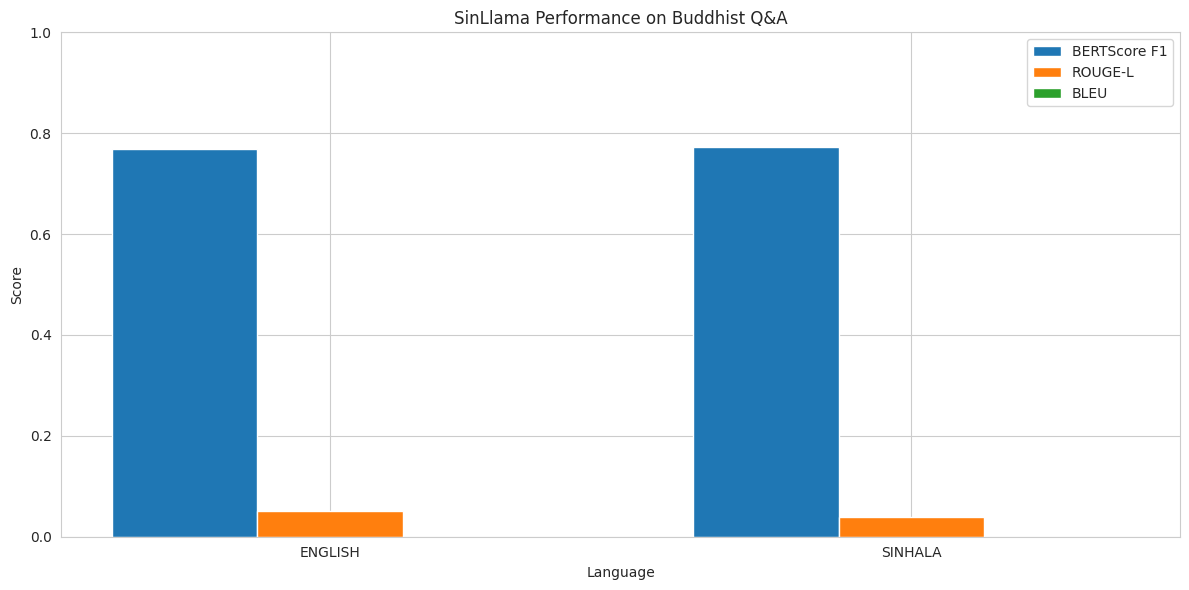


✅ Visualization complete!


In [ ]:
"""
📊 Create Visualizations
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Prepare data for plotting
metrics_to_plot = ['bertscore_f1', 'rougeL', 'bleu']
metric_labels = ['BERTScore F1', 'ROUGE-L', 'BLEU']

languages = [r['language'].upper() for r in all_results]
metric_values = {
    label: [r['metrics'][metric] for r in all_results]
    for label, metric in zip(metric_labels, metrics_to_plot)
}

# Create bar plot
fig, ax = plt.subplots()
x = range(len(languages))
width = 0.25

for i, (label, values) in enumerate(metric_values.items()):
    offset = width * (i - 1)
    ax.bar([p + offset for p in x], values, width, label=label)

ax.set_xlabel('Language')
ax.set_ylabel('Score')
ax.set_title('SinLlama Performance on Buddhist Q&A')
ax.set_xticks(x)
ax.set_xticklabels(languages)
ax.legend()
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\n✅ Visualization complete!")

## 📊 Step 11: Analysis by Difficulty

In [ ]:
"""
📊 Analysis by Question Difficulty
"""

for result in all_results:
    df_resp = pd.DataFrame(result['responses'])

    print(f"\n{'='*60}")
    print(f"{result['language'].upper()} - Questions by Difficulty")
    print(f"{'='*60}")

    for diff in ['easy', 'medium', 'hard']:
        subset = df_resp[df_resp['difficulty'] == diff]
        count = len(subset)
        print(f"\n  {diff.upper()}: {count} questions")

        if count > 0:
            # Show one example from each difficulty
            example = subset.iloc[0]
            print(f"  Example Q{example['question_id']}:")
            print(f"    Question: {example['question'][:60]}...")
            print(f"    Response: {example['model_response'][:80]}...")


ENGLISH - Questions by Difficulty

  EASY: 4 questions
  Example QQ001:
    Question: What are the Four Noble Truths?...
    Response: දුක්ඛ ආර්ය සත්‍යය, සමුදය ආර්ය සත්‍ය​ය (සමුදධ), නිරෝධි ආර්ය්‍යසත්‍ය සහ මාර්ග සත්ත...

  MEDIUM: 4 questions
  Example QQ002:
    Question: How are the eight factors of the Noble Eightfold Path catego...
    Response: සම්මා දිට්ඨිය, සම්මා සංකප්පය සහ ඉතිරි අංග තුන පිළිවෙලින්.ඒ වගේමයි මේ කරුණු අටම ත...

  HARD: 2 questions
  Example QQ005:
    Question: What are the twelve links of Dependent Origination?...
    Response: අ, ආ, ඇ‍ෙඩ් ඉ ඊ උ ඌ එ ඒ ඔ ඕ ක ඛ ග ද ධ න වක ණ ම හ ළ බ ල ව ශ ෂ ස ර ජ ට ඩ ඡ ප ඵ ථ ත...

SINHALA - Questions by Difficulty

  EASY: 4 questions
  Example QQ001:
    Question: සතර ආර්ය සත්‍යය මොනවාද?...
    Response: දුක්ඛ සත්‍ය, සමුදය සත්‍ය, නිරෝධ සත්‍ය සහ මාර්ග සත්‍යය.මේවා බුදු රජාණන් වහන්සේ වි...

  MEDIUM: 4 questions
  Example QQ002:
    Question: ආර්ය අෂ්ඨාංගික මාර්ගයේ අංග අටම වර්ග කරන්නේ කෙසේද?...
    Response: සම්මා දිට්ඨි, අවිද්‍යාව ප්

## 💾 Step 12: Save Results

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
"""
💾 Save Evaluation Results
"""

import json
from datetime import datetime

# Save as JSON
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"/content/drive/MyDrive/Ranidu/University/Year 4/IRP/Results/sinllama_buddhist_eval_{timestamp}.json"

with open(filename, 'w', encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

print(f"\n✅ Results saved to: {filename}")

# Also save comparison table as CSV
csv_filename = f"/content/drive/MyDrive/Ranidu/University/Year 4/IRP/Results/sinllama_comparison_{timestamp}.csv"
df_comparison.to_csv(csv_filename, index=False)

print(f"✅ Comparison table saved to: {csv_filename}")


✅ Results saved to: /content/drive/MyDrive/Ranidu/University/Year 4/IRP/Results/sinllama_buddhist_eval_20251030_124619.json
✅ Comparison table saved to: /content/drive/MyDrive/Ranidu/University/Year 4/IRP/Results/sinllama_comparison_20251030_124619.csv
